In [1]:
import numpy as np
import os, os.path
from PIL import Image
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from sklearn.utils import shuffle
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import cv2
import seaborn as sns
import pandas as pd

# Eye extraction implementation
It is necessary to perform eye extraction before loading the dataset so that, prior to resizing, the images can be normalized in terms of aspect ratio.

In [3]:
def eye_extraction(image: list) -> list:
  '''
  Calculates the borders of an eye so that the background can be deleted.
  Also gets converted from RGB to a grayscale image.

  Args:
    image (list): 3D matrix containing information about the image.

  Returns:
    list: A list containing 4 coordiantes of borders of the eye.
  '''
  image = rgb2gray(image)
  h, w = image.shape
  image = image * 255
  found_pixel = False
  threshold = 30
  x1, y1, x2, y2 = 0, 0, 0 , 0
  for i in range(h):
      for j in range(w):
        if image[i][j] > threshold:
            y1, found_pixel = i, True
            break
      if found_pixel:
          break

  found_pixel = False

  for j in range(w):
      for i in range(h):
          if image[i][j] > threshold:
            x1, found_pixel = j, True
            break
      if found_pixel:
          break


  found_pixel = False
  for i in range(h -1, -1, -1):
      for j in range(w -1, -1, -1):
          if image[i][j] > threshold:
            y2, found_pixel = i, True
            break
      if found_pixel:
          break


  found_pixel = False
  for j in range(w - 1, -1, -1):
      for i in range(h - 1, -1, -1):
          if image[i][j] > threshold:
              x2, found_pixel = j, True
              break
      if found_pixel:
          break

  return [x1, y1, x2, y2]

def rescale_image(coordinates: list, image: list) -> list:
  '''
  Rescales the image from the original to given coordinates.

  Args:
    coordinates (list): A list containing pairs of coordinates (x1, y1, x2, y2).
    image (list): A 2D list representing the image.

  Returns:
    list: The rescaled image.
  '''
  image = rgb2gray(image)
  x1, y1, x2, y2 = coordinates
  conv_img = np.zeros((y2 - y1, x2 - x1))
  for i in range(x2 - x1):
    for j in range(y2 - y1):
      conv_img[j][i] = image[j + y1][i + x1]
  return conv_img

Image edit example

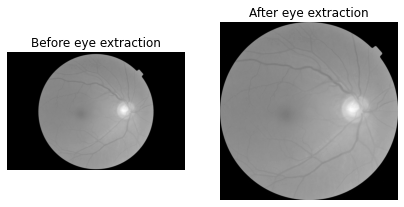

In [43]:
img = Image.open("dataset/glaucoma/Glaucoma_101.png")
img = np.array(img)
coordinates = eye_extraction(img)
converted_image = rescale_image(coordinates, img)
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
ax[0].imshow(rgb2gray(img), cmap='gray')
ax[0].set_title('Before eye extraction')
ax[1].imshow(converted_image, cmap='gray')
ax[1].set_title('After eye extraction')
for a in ax:
    a.axis('off')
plt.show()

# Image loading

In [4]:
data_folder = "dataset"

class_names = os.listdir(data_folder)

data = []
labels = []

for class_name in class_names:
    class_folder = os.path.join(data_folder, class_name)
    for filename in os.listdir(class_folder):
        img_path = os.path.join(class_folder, filename)
        img = Image.open(img_path)
        img = img.resize((224, 224))
        img_array = np.array(img)
        data.append(img_array)
        labels.append(class_name)

Converting images into train, test and validation sets.

In [5]:
data, labels = shuffle(data, labels, random_state=42)
le = preprocessing.LabelEncoder()
labels_encoded = le.fit_transform(labels)

train_data, test_data_temp, train_labels, test_labels_temp = train_test_split(data, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded)
test_data, val_data, test_labels, val_labels = train_test_split(test_data_temp, test_labels_temp, test_size=0.5, random_state=42, stratify=test_labels_temp)

train_data = np.array(train_data)
test_data = np.array(test_data)
val_data = np.array(val_data)
y_train = np.array(train_labels)
y_test = np.array(test_labels)
y_val = np.array(val_labels)
del data, img_array, img, img_path, labels

In [6]:
converted_train_data = []
converted_test_data = []
converted_val_data = []

for image in train_data:
  coordinates = eye_extraction(image)
  im = rescale_image(coordinates, image)
  im = cv2.resize(im, (224,224))
  converted_train_data.append(im)

for image in test_data:
  coordinates = eye_extraction(image)
  im = rescale_image(coordinates, image)
  im = cv2.resize(im, (224,224))
  converted_test_data.append(im)

for image in val_data:
  coordinates = eye_extraction(image)
  im = rescale_image(coordinates, image)
  im = cv2.resize(im, (224,224))
  converted_val_data.append(im)

del train_data, test_data, val_data

Example results

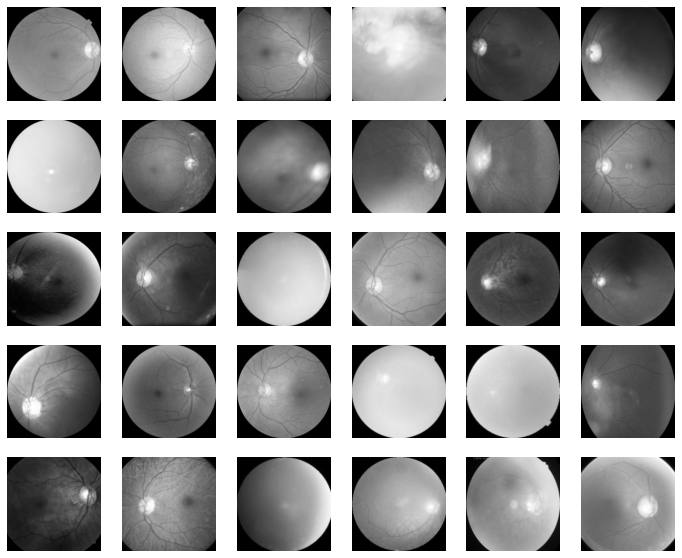

In [7]:
fig, axes = plt.subplots(5, 6, figsize=(12, 10))

for i in range(30):
    ax = axes[i // 6, i % 6]
    ax.imshow(converted_test_data[i], cmap='gray')
    ax.axis('off')

plt.show()

Saving images

In [7]:
home = "images"
directories = "train", "test", "val"

os.makedirs(home)
for dir in directories:
    os.makedirs(f'{home}/{dir}')

In [8]:
for i, train in enumerate(converted_train_data):
    plt.imsave(f'{home}/{directories[0]}/train{i}.png', train, cmap='gray')
for i, test in enumerate(converted_test_data):
    plt.imsave(f'{home}/{directories[1]}/test{i}.png', test, cmap='gray')
for i, val in enumerate(converted_val_data):
    plt.imsave(f'{home}/{directories[2]}/val{i}.png', val, cmap='gray')

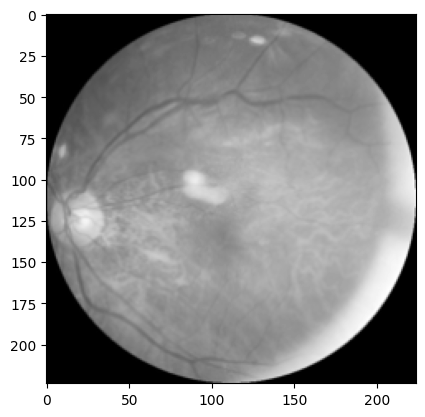

In [9]:
plt.imshow(converted_train_data[0], cmap='gray')

Saving labels

In [10]:
with open(f'{home}/train.txt', 'w') as f:
    for line in y_train:
        f.write(str(line) + '\n')
with open(f'{home}/test.txt', 'w') as f:
    for line in y_test:
        f.write(str(line) + '\n')
with open(f'{home}/val.txt', 'w') as f:
    for line in y_val:
        f.write(str(line) + '\n')

In [11]:
data_folder = "dataset"
class_names = os.listdir(data_folder)
lengths = []
for class_name in class_names:
    class_folder = os.path.join(data_folder, class_name)
    _, _, files = next(os.walk(class_folder))
    lengths.append(len(files))

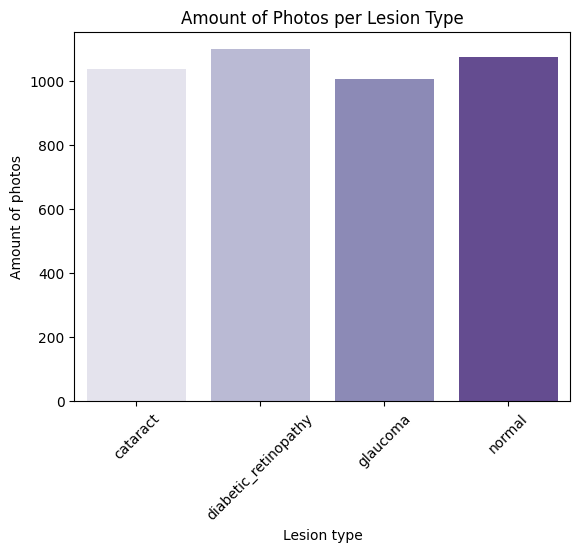

In [16]:
data = pd.DataFrame({
    'class_names': class_names,
    'lengths': lengths
})

sns.barplot(x='class_names', y='lengths', hue='class_names', data=data, palette='Purples')
plt.xlabel('Lesion type')
plt.ylabel('Amount of photos')
plt.title('Amount of Photos per Lesion Type')
plt.xticks(rotation=45)
plt.show()

## Dataset
https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification